# ZeRO-1, ZeRO-2, ZeRO-3 on 32 virtual GPUs

32 GPUs faked with CPU threads. Train a small transformer 4 ways and measure what changes.

- **Ψ** = number of parameters. **N** = number of GPUs.
- Every memory / network number here is **counted**, not estimated.
- Runtime ~2 min. CPU runtime is fine — no GPU used.
- No speed claims anywhere: 32 Python threads measure Python, not ZeRO.

In [1]:
# --- bootstrap: works on a fresh Colab runtime and locally, unchanged ---------
import os, sys, subprocess, time
T_START = time.time()

REPO   = "https://github.com/LokeshJatangi/Distributed-Training-Mock.git"
FOLDER = "Distributed-Training-Mock"

def _find_vzero(start=None):
    d = os.path.abspath(start or os.getcwd())
    for _ in range(4):
        if os.path.isdir(os.path.join(d, "vzero")):
            return d
        d = os.path.dirname(d)
    return None

root = _find_vzero()
if root is None:                       # Colab, or anywhere the repo is not already here
    dest = os.path.abspath(os.path.join("/content" if os.path.isdir("/content") else ".", FOLDER))
    if not os.path.isdir(dest):
        subprocess.run(["git", "clone", "--depth", "1", "--branch", "main", REPO, dest],
                       check=True)
    root = dest
    if not os.path.isdir(os.path.join(root, "vzero")):
        raise RuntimeError(f"vzero not found in {dest}")

sys.path.insert(0, root)
os.chdir(root)

for pkg in ("torch", "numpy", "matplotlib"):        # all preinstalled on Colab
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

from vzero.env import configure
ENV = configure()
print(ENV.render())
print(f"  working dir   {os.getcwd()}")

provenance
  python         3.12.2
  torch          2.9.1+cu128
  platform       Linux-6.8.0-139-generic-x86_64-with-glibc2.39 (x86_64)
  cpu_count      12
  colab          False
  vzero sha256   ff620a58469d0fd7
  working dir   /home/kakashi/ERA_V5 assignments/Distributed Training Mock


## 1. The problem

GPT-2 XL (1.5B params), one 16 GB card, Adam + mixed precision:

| what | size |
|---|---|
| fp16 weights | 3 GB |
| fp16 gradients | 3 GB |
| fp32 master weights | 6 GB |
| Adam `m` | 6 GB |
| Adam `v` | 6 GB |
| **total** | **24 GB** |

- 16 bytes per parameter. Doesn't fit, and that's before activations.
- **18 of those 24 GB are identical on every GPU.**
- A 33rd GPU doesn't shrink it. Data parallel = more speed, zero memory help.

In [2]:
from vzero.analysis import REGIMES, STAGES, STAGE_NAMES, state_bytes_per_gpu, paper_table

print("bytes per parameter, by accounting regime\n")
print(f"{'regime':14}{'params':>9}{'grads':>8}{'optimizer':>11}{'total':>8}")
for name, (p, g, o) in REGIMES.items():
    print(f"{name:14}{p:>9}{g:>8}{o:>11}{p+g+o:>8}")
print("\nBoth = 16 bytes/param. Same total, different shardable fraction.")

bytes per parameter, by accounting regime

regime           params   grads  optimizer   total
fp32_adam             4       4          8      16
mixed_paper           2       2         12      16

Both = 16 bytes/param. Same total, different shardable fraction.


Written as a formula: **16Ψ** bytes of model state per GPU. The paper writes it 2Ψ + 2Ψ + KΨ, K=12.

**Watch out:** fp32+Adam is *also* 16 bytes/param (4+4+8). Same total, but:

- ZeRO-1 shards only the optimizer.
- That's **8/16** of the total in fp32, **12/16** in mixed precision.
- So the same ZeRO-1 saves **1.94×** in one and **3.66×** in the other.

This notebook runs fp32, so it reports the weaker column.

In [3]:
N = 32
print(f"per-GPU model state at N={N}, as a multiple of Psi\n")
print(f"{'regime':14}" + "".join(f"{STAGE_NAMES[s]:>16}" for s in STAGES) + f"{'stage-1 saving':>16}")
for reg in REGIMES:
    v = [state_bytes_per_gpu(s, 1, N, reg) for s in STAGES]
    print(f"{reg:14}" + "".join(f"{x:>16.3f}" for x in v) + f"{v[0]/v[1]:>15.2f}x")

print("\n\ncheck the formulas against Table 1 of the ZeRO paper (arXiv:1910.02054), N=64\n")
print(f"{'Psi':>8}{'stage':>8}{'mine (GB)':>12}{'paper (GB)':>12}")
ok = True
for row in paper_table():
    for s in STAGES:
        mine, paper = row[f"stage{s}"], row[f"paper{s}"]
        ok &= abs(mine - paper) <= max(0.05, 0.01 * paper)
        print(f"{row['psi']/1e9:>7.1f}B{s:>8}{mine:>12.2f}{paper:>12.2f}")
assert ok, "formulas do not reproduce the paper"
print("\nevery published number reproduced.")

per-GPU model state at N=32, as a multiple of Psi

regime            ZeRO-0 (DDP)          ZeRO-1          ZeRO-2          ZeRO-3  stage-1 saving
fp32_adam               16.000           8.250           4.375           0.500           1.94x
mixed_paper             16.000           4.375           2.438           0.500           3.66x


check the formulas against Table 1 of the ZeRO paper (arXiv:1910.02054), N=64

     Psi   stage   mine (GB)  paper (GB)
    7.5B       0      120.00      120.00
    7.5B       1       31.41       31.40
    7.5B       2       16.64       16.60
    7.5B       3        1.88        1.88
  128.0B       0     2048.00     2048.00
  128.0B       1      536.00      536.00
  128.0B       2      284.00      284.00
  128.0B       3       32.00       32.00

every published number reproduced.


## 2. The virtual GPUs

Each = one thread + a ledger that counts bytes.

- Threads not processes: 32 torch imports = 8–11 GB RSS, and memory would have to be read from noisy RSS instead of counted.
- Tensors keyed by **storage address**, so a `.view()` costs 0 bytes.
- The ledger holds a reference to each storage, so a recycled address can't be mistaken for one already counted.

In [4]:
import gc, torch
from vzero.vgpu import MemArena, VGPUOutOfMemory

a = MemArena(rank=0)
t = a.alloc(1000, bucket="params", name="flat")
assert a.live_total == 4000
a.adopt(t.narrow(0, 0, 500), bucket="act", name="a_view")
assert a.live_total == 4000, f"a view was double-counted: {a.live_total}"
a.free(t); assert a.live_total == 0 and a.peak_total == 4000
print("views add zero bytes; peak is a watermark        OK")

b = MemArena(rank=1, capacity_bytes=4096)
b.alloc(1000, bucket="params", name="first")   # reference dropped on purpose
gc.collect()                                   # storage freed, address reusable
try:
    b.alloc(1000, bucket="params", name="second")
    print("FAIL: address reuse aliased a live record")
except VGPUOutOfMemory as e:
    print("address reuse cannot alias a live record       OK")
    print(f"  and a virtual GPU can run out of memory:\n  {e}")

views add zero bytes; peak is a watermark        OK
address reuse cannot alias a live record       OK
  and a virtual GPU can run out of memory:
  rank 1: allocating 4,000 B for params/'second' during phase 'init' would take live memory from 4,000 B to 8,000 B, over the 4,096 B capacity of this virtual GPU


## 3. The ring

4 ranks, 4 numbers each, everyone wants the sum. Split into chunks, go round twice:

```
reduce-scatter   N-1 steps -> each rank owns the full sum of one chunk
all-gather       N-1 steps -> everyone ends up with all chunks
```

- Each phase moves `(N-1)/N · Ψ` per rank → the pair is `2(N-1)/N · Ψ`.
- That pair **is** an all-reduce. Section 7 depends on this.
- The addition order is fixed by the algorithm: chunk `c` starts at rank `c+1`, wraps, `c` adds last.
- Float addition isn't associative, so that order is part of the answer.

In [5]:
# A standalone ring reduce-scatter, written out for four ranks so the order of
# additions is visible. The production fabric does exactly this; the cell after
# next checks the two agree bitwise.
import torch

def ring_reduce_scatter_trace(contribs):
    N = len(contribs)
    C = contribs[0].numel() // N
    work = [c.clone() for c in contribs]
    print(f"{'step':>5}  who sends which chunk to whom")
    for k in range(N - 1):
        moves, snap = [], [w.clone() for w in work]
        for r in range(N):
            idx = (r - 1 - k) % N
            moves.append(f"r{r}->r{(r+1)%N}:c{idx}")
            recv_idx = (r - 2 - k) % N
            work[r].narrow(0, recv_idx * C, C).add_(snap[(r - 1) % N].narrow(0, recv_idx * C, C))
        print(f"{k:>5}  " + "   ".join(moves))
    return [work[r].narrow(0, r * C, C).clone() for r in range(N)]

g = torch.Generator().manual_seed(0)
contribs = [torch.randn(4, generator=g) for _ in range(4)]
owned = ring_reduce_scatter_trace(contribs)

print(f"\nafter {4-1} steps each rank owns the full sum of its own chunk:")
for r in range(4):
    print(f"  rank {r} owns chunk {r} = {owned[r].item():+.6f}")
print(f"\nplain sum for comparison:      {[f'{v:+.6f}' for v in sum(contribs).tolist()]}")

from vzero.fabric import accumulation_order
print(f"\naddition order for each chunk (c+1, c+2, ..., c last):")
for c in range(4):
    print(f"  chunk {c}: " + " + ".join(f"contrib[{r}]" for r in accumulation_order(c, 4)))

 step  who sends which chunk to whom
    0  r0->r1:c3   r1->r2:c0   r2->r3:c1   r3->r0:c2
    1  r0->r1:c2   r1->r2:c3   r2->r3:c0   r3->r0:c1
    2  r0->r1:c1   r1->r2:c2   r2->r3:c3   r3->r0:c0

after 3 steps each rank owns the full sum of its own chunk:
  rank 0 owns chunk 0 = -1.119458
  rank 1 owns chunk 1 = -0.994764
  rank 2 owns chunk 2 = -3.443265
  rank 3 owns chunk 3 = +1.711195

plain sum for comparison:      ['-1.119458', '-0.994764', '-3.443265', '+1.711195']

addition order for each chunk (c+1, c+2, ..., c last):
  chunk 0: contrib[1] + contrib[2] + contrib[3] + contrib[0]
  chunk 1: contrib[2] + contrib[3] + contrib[0] + contrib[1]
  chunk 2: contrib[3] + contrib[0] + contrib[1] + contrib[2]
  chunk 3: contrib[0] + contrib[1] + contrib[2] + contrib[3]


In [6]:
# The production fabric, checked three ways at the real world size of 32.
from vzero.fabric import Fabric, ring_bytes
from vzero.pool import run_workers

W, P = 32, 32 * 16 * 3
src = [torch.randn(P, generator=torch.Generator().manual_seed(i)) for i in range(W)]

# (a) all_reduce is literally reduce_scatter + all_gather, bitwise
f1 = Fabric(W); ar = [s.clone() for s in src]
run_workers(W, lambda r: f1.all_reduce(r, ar[r], key="a", op="mean"), f1)
f2 = Fabric(W); sh = [torch.empty(P // W) for _ in range(W)]; full = [torch.empty(P) for _ in range(W)]
def rs_ag(r):
    f2.reduce_scatter(r, src[r].clone(), sh[r], key="rs", op="mean")
    f2.all_gather(r, sh[r], full[r], key="ag")
run_workers(W, rs_ag, f2)
assert all(torch.equal(ar[r], full[r]) for r in range(W))
print("all_reduce == reduce_scatter + all_gather, bitwise on all 32 ranks   OK")

# (b) the cheap path and a real 31-step ring agree on bits AND on bytes
res = {}
for impl in ("direct", "ring"):
    f = Fabric(W, impl=impl); s_ = [torch.empty(P // W) for _ in range(W)]; o_ = [torch.empty(P) for _ in range(W)]
    def work(r, f=f, s_=s_, o_=o_):
        f.reduce_scatter(r, src[r].clone(), s_[r], key="rs", op="mean")
        f.all_gather(r, s_[r], o_[r], key="ag")
    run_workers(W, work, f)
    res[impl] = (o_, f.totals()["per_rank_sent"])
assert all(torch.equal(res["direct"][0][r], res["ring"][0][r]) for r in range(W))
assert res["direct"][1] == res["ring"][1]
print("the fast path is bit- and byte-identical to a real 31-step ring       OK")

# (c) the byte counters equal the closed form exactly -- no slack
want = ring_bytes("reduce_scatter", P, W) + ring_bytes("all_gather", P, W)
assert want == ring_bytes("all_reduce", P, W)
assert all(f2.stats[r].bytes_sent == want for r in range(W))
print(f"byte counters == 2(N-1)/N x P x 4 = {want:,} B, exactly, every rank   OK")

all_reduce == reduce_scatter + all_gather, bitwise on all 32 ranks   OK


the fast path is bit- and byte-identical to a real 31-step ring       OK
byte counters == 2(N-1)/N x P x 4 = 11,904 B, exactly, every rank   OK


## 4. The model and how it's cut up

Small decoder-only transformer: vocab 509, d_model 64, 4 heads, 4 layers, seq 64, untied head.

Three deliberate choices:

- Ψ is **not** a multiple of 32 → padding is real, not hidden by tidy numbers.
- Head is untied. A tied head is used twice in forward, so a grad hook fires twice on a half-finished gradient.
- Sharding is **per group** (embeddings, each block, final norm, head), and **all 4 modes use the same grouping**.

That last one matters: the ring's addition order depends on which chunk an element lands in. Same grouping → same order → the bitwise check in section 8 is possible.

In [7]:
from vzero.model import PRESETS
cfg = PRESETS["xs"]
space = cfg.space(32)
r = space.report()
print(f"Psi = {r['psi']:,}   Psi mod 32 = {r['psi'] % 32}   -> padding is unavoidable\n")
print(space.table())
print(f"\nlargest group   {r['max_group_numel']:,} elements  -> sets ZeRO-3's transient buffer")
print(f"straddling      {r['n_straddling']}/{r['n_params']} params cross a shard boundary (up to {r['max_pieces']} ranks)")
print(f"worst padding   ln_f: 128 -> 512 elements = 75% waste")

Psi = 269,821   Psi mod 32 = 29   -> padding is unavoidable

group            raw    padded    shard    pad    pad%
embed         36,672    36,864    1,152    192   0.52%
block0        49,984    50,176    1,568    192   0.38%
block1        49,984    50,176    1,568    192   0.38%
block2        49,984    50,176    1,568    192   0.38%
block3        49,984    50,176    1,568    192   0.38%
ln_f             128       512       16    384  75.00%
head          33,085    33,280    1,040    195   0.59%
TOTAL        269,821   271,360    8,480  1,539   0.57%

largest group   50,176 elements  -> sets ZeRO-3's transient buffer
straddling      25/54 params cross a shard boundary (up to 32 ranks)
worst padding   ln_f: 128 -> 512 elements = 75% waste


## 5. The four modes

Only three things differ: where weights live, where gradients live, where optimizer state lives.

| | weights | gradients | optimizer | collectives |
|---|---|---|---|---|
| **ZeRO-0** | full | full | full | `all_reduce(grads)` |
| **ZeRO-1** | full | full | **shard** | `reduce_scatter` + `all_gather` |
| **ZeRO-2** | full | **shard** | **shard** | same two, gradients freed early |
| **ZeRO-3** | **shard** | **shard** | **shard** | `all_gather` ×2 + `reduce_scatter` |

- ZeRO-1 vs ZeRO-2: **same collectives, same payloads.** Only difference is when gradients are freed.
- ZeRO-3's hard part: autograd saves the weight for backward, so dropping a reference frees nothing. Fix is FSDP's — resize the storage to 0 bytes, resize back before backward.
- That's why ZeRO-3 can use plain `F.linear` / `F.embedding` / `F.layer_norm`, and why it comes out bitwise identical to the rest.

Code below is read straight from the module with `inspect.getsource` — it's what actually ran.

In [8]:
import inspect
from vzero.engine import GroupState, Worker

for fn in (Worker._finish_ddp, Worker._finish_zero1, Worker._finish_sharded,
           Worker._install_grad_hooks):
    print(inspect.getsource(fn))

    def _finish_ddp(self) -> None:
        """Every rank all-reduces the whole gradient and performs the identical
        Adam update. 32 ranks doing the same arithmetic 32 times."""
        for gid, gs in self.groups.items():
            pad = gs.padded - self.space.groups[gid].raw_numel
            if self.rc.ablation != "no_reduce":
                self.fab.all_reduce(self.rank, gs.full.grad, key=f"ar/{gid}",
                                    op=self._op(), pad_numel=pad)
            self.arena.note_phase("opt")
            gs.opt.step(gs.full_d, gs.full.grad)
            gs.full.grad.zero_()

    def _finish_zero1(self) -> None:
        """Gradients stay fully resident; only the optimizer state is sharded."""
        for gid, gs in self.groups.items():
            pad = gs.padded - self.space.groups[gid].raw_numel
            if self.rc.zero1_naive:
                # The footgun: all_reduce then take a slice. Correct loss, same
                # memory as the efficient version, 

In [9]:
print(inspect.getsource(GroupState.materialise))
print(inspect.getsource(GroupState.reshard))

    def materialise(self, fab: Fabric, tag: str) -> None:
        """all_gather this group's parameters into a live buffer.

        The write has to happen without bumping the version counter. Autograd
        saved views of this exact storage during forward and records the version
        it saw; re-gathering into it in backward would look like "a variable
        needed for gradient computation was modified in place" and raise. The
        escape hatch is the one real FSDP2 uses at its own all-gather copy-out --
        see torch/distributed/fsdp/_fully_shard/_fsdp_collectives.py, which wraps
        the same operation in the same context manager.
        """
        if self.gathered:
            return
        with torch.autograd._unsafe_preserve_version_counter(self.full_d):
            self.full_d.untyped_storage().resize_(self._nbytes)
            self.arena.adopt(self.full_d, bucket="transient", name=f"{self.gid}.gathered")
            fab.all_gather(self.rank, self.shard, self

## 6. Run all four

Same model, same seeds, same data, 32 virtual GPUs. Only the sharding changes.

In [10]:
import time
from vzero.engine import RunConfig, run, Reference

STEPS = 12
runs, timings = {}, {}
for m in STAGES:
    t = time.perf_counter()
    runs[m] = run(cfg, RunConfig(mode=m, world=32, steps=STEPS))
    timings[m] = time.perf_counter() - t
    print(f"  ZeRO-{m} done in {timings[m]:5.1f}s")

ref = Reference(cfg, RunConfig(world=32, steps=STEPS), order="ring").run()
naive = run(cfg, RunConfig(mode=1, world=32, steps=STEPS, zero1_naive=True))
per_step = {m: runs[m].comm["per_rank_sent"][0] // STEPS for m in STAGES}
print(f"\nloss {runs[0].losses_mean[0]:.4f} -> {runs[0].losses_mean[-1]:.4f}"
      f"   (random guessing = ln(509) = {__import__('math').log(cfg.vocab):.4f})")

  ZeRO-0 done in   6.5s


  ZeRO-1 done in   6.3s


  ZeRO-2 done in   6.8s


  ZeRO-3 done in   8.1s



loss 6.7188 -> 6.3979   (random guessing = ln(509) = 6.2324)


In [11]:
MB = 1 << 20
b0 = runs[0].peak_breakdown[0]
st0 = sum(b0[k] for k in ("params", "grads", "opt"))
p0 = runs[0].peak_total[0]
print(f"{'mode':16}{'state/rank':>12}{'vs DDP':>9}{'peak/rank':>12}{'vs DDP':>9}"
      f"{'comm/step':>12}{'vs DDP':>9}{'collectives':>12}")
for m in STAGES:
    b = runs[m].peak_breakdown[0]
    st = sum(b[k] for k in ("params", "grads", "opt"))
    pk = runs[m].peak_total[0]
    print(f"{STAGE_NAMES[m]:16}{st/MB:>11.3f}M{st0/st:>8.2f}x{pk/MB:>11.3f}M{p0/pk:>8.2f}x"
          f"{per_step[m]/MB:>11.3f}M{per_step[m]/per_step[0]:>8.4f}x"
          f"{runs[m].comm['per_rank_n'][0]//STEPS:>12}")

st3 = sum(runs[3].peak_breakdown[0][k] for k in ("params", "grads", "opt"))
print(f"\n  ZeRO-3 model state   {st0/st3:.2f}x less   (theory says 32x)")
print(f"  ZeRO-0/1/2 network   {per_step[0]:,} B each, identical to the byte")
print(f"  ZeRO-3 network       {per_step[3]/per_step[0]:.4f}x DDP")
print(f"  but PEAK memory      only {p0/runs[3].peak_total[0]:.2f}x less. Next figure says why.")

mode              state/rank   vs DDP   peak/rank   vs DDP   comm/step   vs DDP collectives
ZeRO-0 (DDP)          4.141M    1.00x      5.567M    1.00x      2.006M  1.0000x          14
ZeRO-1                2.167M    1.91x      3.594M    1.55x      2.006M  1.0000x          14
ZeRO-2                1.132M    3.66x      2.558M    2.18x      2.006M  1.0000x          14
ZeRO-3                0.129M   32.00x      1.670M    3.33x      3.008M  1.5000x          21

  ZeRO-3 model state   32.00x less   (theory says 32x)
  ZeRO-0/1/2 network   2,103,040 B each, identical to the byte
  ZeRO-3 network       1.5000x DDP
  but PEAK memory      only 3.33x less. Next figure says why.


### What shrinks

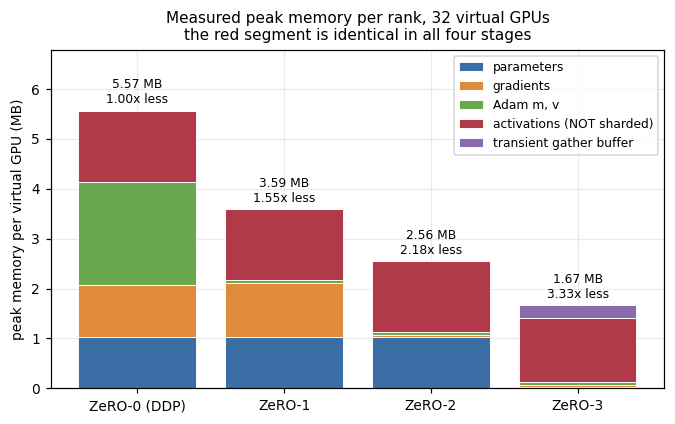

In [12]:
from vzero import report
from IPython.display import Image, display
import os
os.makedirs("figures", exist_ok=True)
display(Image(report.fig_memory_breakdown(runs, "figures/01-memory-breakdown.png")))

Each stage removes exactly the piece it claims to: Adam state, then gradients, then weights.

**The red segment never moves.** ZeRO splits model state. Activations aren't model state, so they're untouched — same bytes in all 4 modes, on all 32 ranks (both asserted).

- Model state drops **32×**.
- Peak memory drops much less, because activations are most of what's left.
- Fix for that is activation checkpointing. Different tool, not ZeRO.

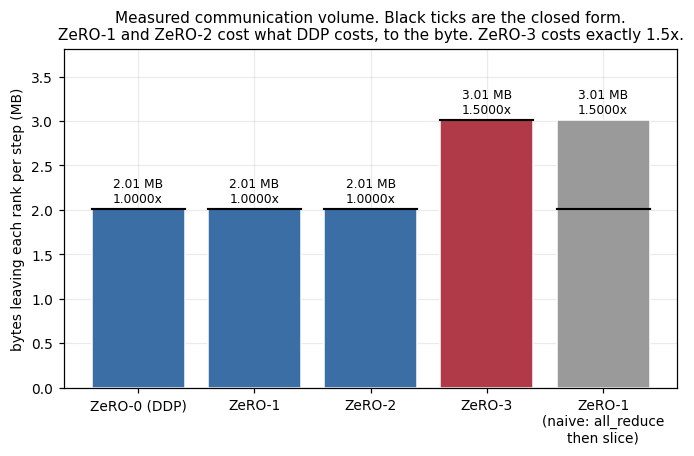

In [13]:
display(Image(report.fig_comm_volume(per_step, naive.comm["per_rank_sent"][0] // STEPS,
                                     space.psi_padded, 32, "figures/03-comm-volume.png")))

## 7. Why ZeRO-1 and ZeRO-2 are free

Natural guess: DDP = 1 collective, ZeRO-1 = 2, so ZeRO-1 costs more.

Wrong, because **DDP's one collective is already two**: a ring all-reduce *is* reduce-scatter + all-gather.

- ZeRO-1 does the same two phases.
- Difference: its all-gather carries **updated weights** instead of **reduced gradients**. Same element count.
- The optimizer step just moved to sit between the phases instead of after both.
- ZeRO-2 changes neither collective. It only frees gradients earlier.

ZeRO-3 adds a real third phase: weights gathered for forward are freed, so backward gathers again → `3(N-1)/N` = **1.5× exactly**, for every N.

The grey bar is a working ZeRO-1 written the tempting way — all-reduce, then update your shard, then all-gather. Correct, bitwise identical result, same memory, **1.5× the bytes for nothing**. A loss curve would never show it.

## 8. Are all four the same training run?

Plotting loss curves and seeing them overlap is weak evidence — section 9 breaks the code 4 ways and the loss still falls every time.

So the bar here is higher: **all four modes are asserted bitwise identical**, to each other and to a single-GPU reference. Two reasons that's possible:

- `all_reduce` is **built as** reduce-scatter + all-gather → ZeRO-0 adds the same numbers in the same order as ZeRO-1/2/3.
- Adam is element-wise → running it on a slice equals running it on the whole tensor and reading that slice.

In [14]:
from vzero.validate import validate
rep = validate(cfg, world=32, steps=4)
print(rep.render())
assert rep.all_passed

  [PASS] psi not divisible by world                               Psi=269,821, Psi mod 32 = 29 -> padding is real
  [PASS] shards tile the padded space                             32 x 8,480 = 271,360
  [PASS] reference actually learns                                loss 6.7188 -> 6.5504 (fell 0.1684; ln(vocab)=6.232)
  [PASS] ZeRO-0 == ZeRO-1 bitwise                                 max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-0 == ZeRO-2 bitwise                                 max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-0 == ZeRO-3 bitwise                                 max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-0 == ring-order reference bitwise                   max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-0 loss == reference bitwise                         max|dLoss|=0.000e+00
  [PASS] ZeRO-1 == ring-order reference bitwise                   max|delta|=0.000e+00, 0/54 tensors differ
  [PASS] ZeRO-1 loss == reference bitwise            

## 9. Four bugs planted on purpose

A test that has never failed isn't proof it can fail.

- `no_reduce` — never sync gradients across ranks
- `shard_offset` — optimizer updates a slice one element off
- `no_all_gather` — never rebuild weights after the step
- `sum_not_mean` — reduce with sum, forgetting the 1/N

In [15]:
from vzero.engine import RunConfig, run
ABL = ("no_reduce", "shard_offset", "no_all_gather", "sum_not_mean")
abl = {a: run(cfg, RunConfig(mode=2, world=32, steps=STEPS, ablation=a)) for a in ABL}
good = max(abs(x - y) for x, y in zip(runs[2].losses_mean, ref["losses"]))
print(f"{'variant':16}{'max|dLoss|':>13}  {'loss start -> end':>24}   caught by")
print(f"{'correct ZeRO-2':16}{good:>13.3e}  {runs[2].losses_mean[0]:>10.4f} ->{runs[2].losses_mean[-1]:>9.4f}   --")
for a, r in abl.items():
    d = max(abs(x - y) for x, y in zip(r.losses_mean, ref["losses"]))
    fell = "(loss still fell)" if r.losses_mean[-1] < r.losses_mean[0] else ""
    by = "a 1e-4 tolerance" if d > 1e-4 else "ONLY the bitwise check"
    print(f"{a:16}{d:>13.3e}  {r.losses_mean[0]:>10.4f} ->{r.losses_mean[-1]:>9.4f}   {by} {fell}")

variant            max|dLoss|         loss start -> end   caught by
correct ZeRO-2      0.000e+00      6.7188 ->   6.3979   --
no_reduce           2.886e-01      6.7188 ->   6.6427   a 1e-4 tolerance (loss still fell)
shard_offset        2.373e-01      6.7188 ->   6.5675   a 1e-4 tolerance (loss still fell)
no_all_gather       3.887e-01      6.7188 ->   6.7866   a 1e-4 tolerance 
sum_not_mean        4.455e-06      6.7188 ->   6.3979   ONLY the bitwise check (loss still fell)


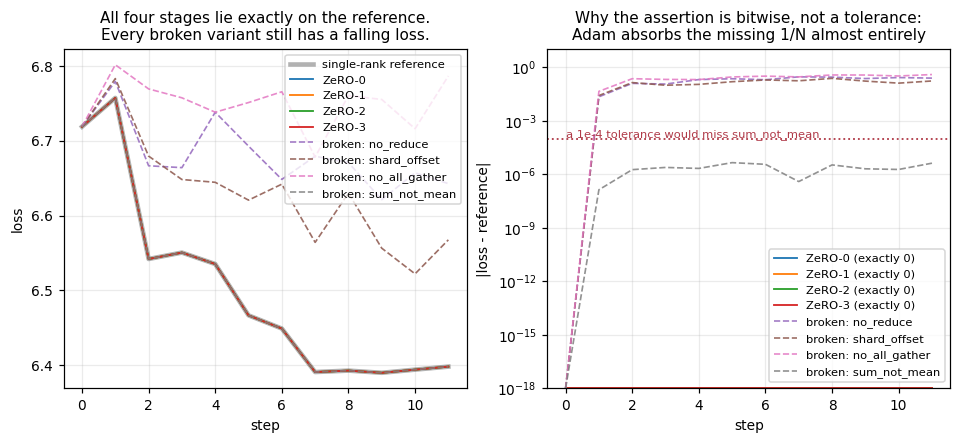

In [16]:
display(Image(report.fig_loss_and_ablations(runs, ref["losses"], abl,
                                            "figures/05-loss-and-ablations.png")))

Three of the four broken variants still lower the loss. "The loss went down" proves nothing.

`sum_not_mean` is the interesting one:

- Gradients come out 32× too big.
- Under SGD that's a 32× learning rate and instant blow-up.
- Under Adam the update is `lr·m/(√v+ε)` — scaling `g` by 32 scales `m` and `√v` by 32, so it cancels. Only trace is ε acting like ε/32.
- Net effect on loss: ~1e-5.

Any tolerance loose enough to survive normal float drift would miss it. The bitwise check catches it. That's what the design in section 8 bought.

## 10. Scaling with N

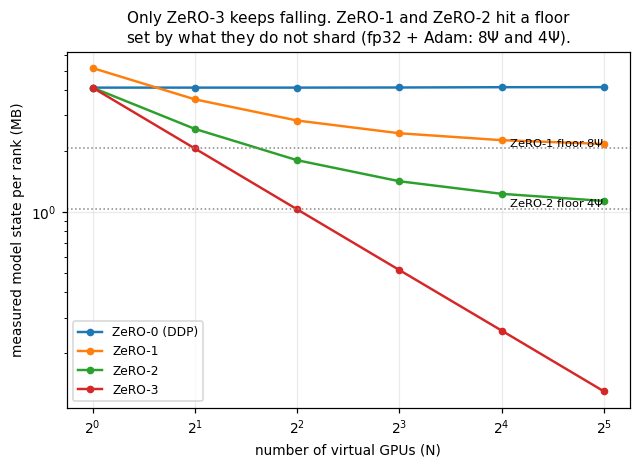

In [17]:
sweep, pad_vs_n, psi_pad_of = {}, {}, {}
for w in (1, 2, 4, 8, 16, 32):
    sp = cfg.space(w)
    psi_pad_of[w], pad_vs_n[w] = sp.psi_padded, sp.report()["pad_frac"]
    sweep[w] = {}
    for m in STAGES:
        b = run(cfg, RunConfig(mode=m, world=w, steps=2)).peak_breakdown[0]
        sweep[w][m] = sum(b[k] for k in ("params", "grads", "opt"))
display(Image(report.fig_memory_vs_world(sweep, psi_pad_of, "figures/04-memory-vs-N.png")))

- ZeRO-1 and ZeRO-2 **flatten out**. Their floors are 8Ψ and 4Ψ in fp32 — set by what they don't shard.
- No number of GPUs gets below a floor.
- Only ZeRO-3 has none, because it shards all three pieces.

That asymptote, not the value at any one N, is the argument for stage 3.

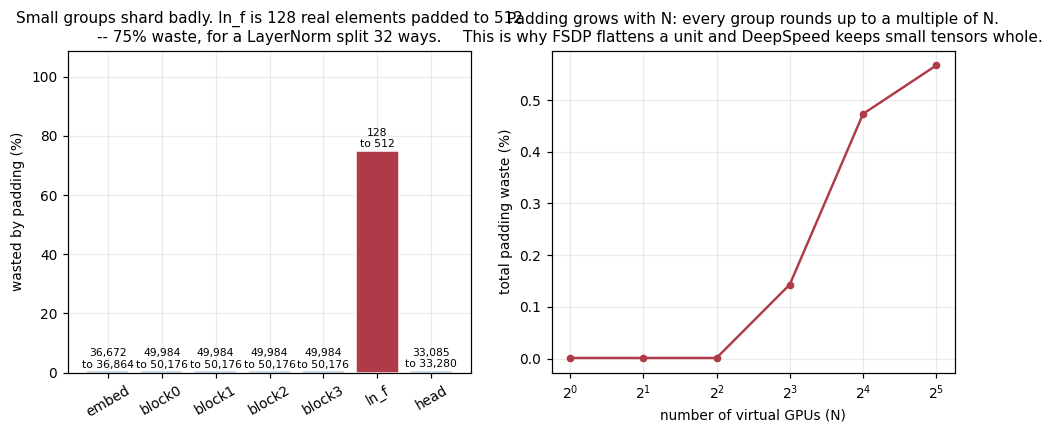

In [18]:
display(Image(report.fig_padding(space.report(), pad_vs_n, "figures/06-padding.png")))

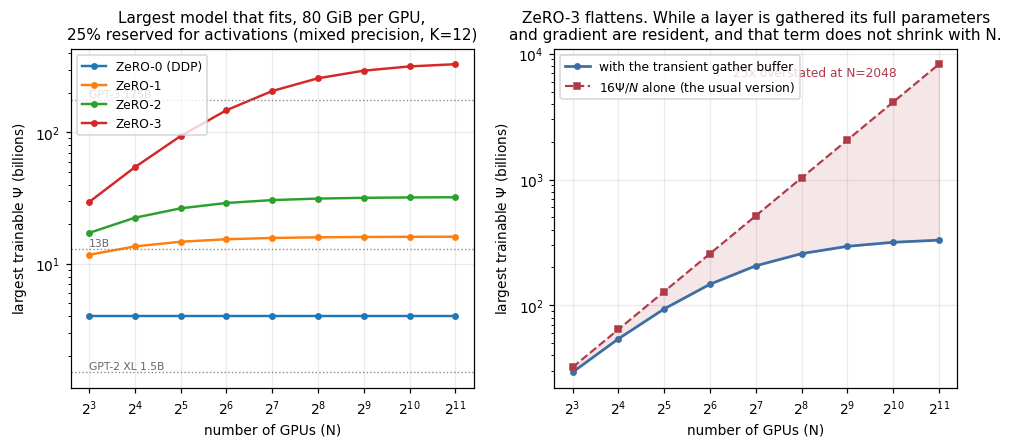

largest trainable Psi: 80 GiB/GPU, 25% held for activations, K=12, 32 layers

     N      ZeRO-0 (DDP)            ZeRO-1            ZeRO-2            ZeRO-3
     8              4.0B             11.7B             17.2B             29.5B
    32              4.0B             14.7B             26.4B             93.7B
    64              4.0B             15.4B             29.0B            147.3B
   512              4.0B             16.0B             31.8B            294.5B

why that last column stops growing -- the transient buffer:
     N       with it     ignoring it   overstated by
    32         93.7B          128.8B              1x
   128        206.2B          515.4B              2x
   512        294.5B         2061.6B              7x
  2048        329.9B         8246.3B             25x


In [19]:
from vzero.analysis import GiB, max_psi
display(Image(report.fig_scaling("figures/07-scaling.png")))

print("largest trainable Psi: 80 GiB/GPU, 25% held for activations, K=12, 32 layers\n")
print(f"{'N':>6}" + "".join(f"{STAGE_NAMES[s]:>18}" for s in STAGES))
for w in (8, 32, 64, 512):
    print(f"{w:>6}" + "".join(
        f"{max_psi(s, 80*GiB, w, regime='mixed_paper', n_layers=32)/1e9:>17.1f}B" for s in STAGES))

print("\nwhy that last column stops growing -- the transient buffer:")
print(f"{'N':>6}{'with it':>14}{'ignoring it':>16}{'overstated by':>16}")
for w in (32, 128, 512, 2048):
    a = max_psi(3, 80*GiB, w, regime="mixed_paper", n_layers=32) / 1e9
    b = 80 * GiB * 0.75 / (16 / w) / 1e9
    print(f"{w:>6}{a:>13.1f}B{b:>15.1f}B{b/a:>15.0f}x")

One term is easy to leave out of a table like this: while a layer is gathered, its **full weights and its full gradient** are live — and that doesn't shrink with N.

- Write ZeRO-3 as `16Ψ/N` alone → claims 8 trillion params at N=2048.
- Include the term → 330 billion. **25× overstated.**

The activation reserve is an assumption too, which is why it's a visible parameter above rather than a footnote.

## 11. Checked against real PyTorch

`torchrun --nproc_per_node=4` on gloo, with real `DistributedDataParallel` and real FSDP2. Both sides call the **same** `vzero.model.forward`, so a mismatch can't be the model.

**Numbers only, on purpose.** gloo has no true reduce-scatter — it runs a full all-reduce and copies out one chunk — so gloo byte counts would contradict correct maths. All communication figures here come from our own ring.

In [20]:
import json, glob
found = sorted(glob.glob("results/crosscheck-world*.json"))
if not found:
    print("cross-check artifacts not present. Run:")
    print("  OMP_NUM_THREADS=1 torchrun --nproc_per_node=4 scripts/torch_crosscheck.py")
else:
    for path in found:
        d = json.load(open(path))
        print(f"world={d['world']}, {d['steps']} steps, gloo probe ok={d['probe']['ok']}")
        for k, v in d["compare"].items():
            if k == "tolerance" or v is None:
                continue
            print(f"   {k:34} max|dLoss| = {v:.3e}   {'PASS' if v < d['compare']['tolerance'] else 'FAIL'}")
        print()

world=1, 15 steps, gloo probe ok=True
   ours_zero0_vs_torch_ddp            max|dLoss| = 9.537e-07   PASS
   ours_zero3_vs_torch_fsdp           max|dLoss| = 9.537e-07   PASS
   torch_ddp_vs_torch_fsdp            max|dLoss| = 0.000e+00   PASS

world=4, 15 steps, gloo probe ok=True
   ours_zero0_vs_torch_ddp            max|dLoss| = 5.960e-07   PASS
   ours_zero3_vs_torch_fsdp           max|dLoss| = 4.768e-07   PASS
   torch_ddp_vs_torch_fsdp            max|dLoss| = 9.537e-07   PASS



**Our ZeRO-0 matches PyTorch's DDP** at both world sizes. That one check covers the threads, the collectives, the model and the data pipeline at once.

FSDP2:

- It **does** run on CPU/gloo — the "FSDP needs NCCL" advice is out of date.
- At world=1, it agrees with DDP bitwise. At world=4, both our ZeRO-3 and PyTorch DDP agree with its loss curve within `1e-6`.

**What can be claimed:** ZeRO-0 is checked against PyTorch DDP, and ZeRO-3's loss curve is checked against FSDP2. All four modes are checked bitwise against a single-GPU reference and each other.

## 12. What's measured and what isn't

**Measured here:** per-GPU memory by category, bytes per collective, collective counts, loss curves, parameter values.

**Calculated, and asserted equal to the measurements:** the 16Ψ accounting, per-stage memory, communication volume, the max-model-size table.

**Not claimed:**

| | |
|---|---|
| speed | 32 threads under the GIL measure Python. No timing chart anywhere. |
| network behaviour | a collective here is a memcpy. Bytes are real, times aren't. |

**Scope:**

- fp32, not mixed precision → the conservative ratios.
- Ψ ≈ 270k, five orders below production.
- N=32 is the only size measured end to end, apart from the sweep above.

In [21]:
print(ENV.render())
print(f"\n  notebook wall-clock   {time.time() - T_START:.1f}s")
print(f"  figures               {len(glob.glob('figures/*.png'))} in figures/")
print(f"  validation            {rep.n_passed}/{len(rep.checks)} checks passed")

provenance
  python         3.12.2
  torch          2.9.1+cu128
  platform       Linux-6.8.0-139-generic-x86_64-with-glibc2.39 (x86_64)
  cpu_count      12
  colab          False
  vzero sha256   ff620a58469d0fd7

  notebook wall-clock   102.0s
  figures               7 in figures/
  validation            32/32 checks passed
